# Version 6.1 : XGBoost Optimisation Complète

**Objectifs** :
1. 📊 Analyser l'importance des features
2. 🎯 Sélectionner les features optimales (éliminer le bruit)
3. ⚙️ Optimiser les hyperparamètres avec Optuna
4. 📈 Comparer baseline vs optimisé

**Approche** :
- Baseline : Toutes les features + avancées (~250 features)
- Optimisé : Features sélectionnées + hyperparamètres optimaux

**Target** : C-index > 0.76

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import optuna

from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported")

✓ Libraries imported


## 2. Data Loading & Feature Engineering

In [2]:
DATA_PATH = r"C:\Users\guill\Desktop\Data Challenge QRT\Data-Challenge-Prediction-de-Survie"

clinical_train = pd.read_csv(f"{DATA_PATH}\\X_train\\clinical_train.csv")
target_train = pd.read_csv(f"{DATA_PATH}\\target_train.csv")
clinical_test = pd.read_csv(f"{DATA_PATH}\\X_test\\clinical_test.csv")
molecular_train = pd.read_csv(f"{DATA_PATH}\\X_train\\molecular_train.csv")
molecular_test = pd.read_csv(f"{DATA_PATH}\\X_test\\molecular_test.csv")

print("✓ Data loaded")

✓ Data loaded


In [3]:
# Feature engineering functions (from V8)
def create_cytogenetic_features(clinical_df):
    cyto_features = pd.DataFrame(index=clinical_df['ID'])
    cyto_col = clinical_df.set_index('ID')['CYTOGENETICS'].fillna('')
    cyto_features['cyto_del_count'] = cyto_col.str.count(r'del\(')
    cyto_features['cyto_has_del'] = (cyto_features['cyto_del_count'] > 0).astype(int)
    cyto_features['cyto_transloc_count'] = cyto_col.str.count(r't\(')
    cyto_features['cyto_has_transloc'] = (cyto_features['cyto_transloc_count'] > 0).astype(int)
    cyto_features['cyto_inv_count'] = cyto_col.str.count(r'inv\(')
    cyto_features['cyto_has_inv'] = (cyto_features['cyto_inv_count'] > 0).astype(int)
    cyto_features['cyto_gain_count'] = cyto_col.str.count(r'\+')
    cyto_features['cyto_has_gain'] = (cyto_features['cyto_gain_count'] > 0).astype(int)
    cyto_features['cyto_loss_count'] = cyto_col.str.count(r'-[0-9XY]')
    cyto_features['cyto_has_loss'] = (cyto_features['cyto_loss_count'] > 0).astype(int)
    cyto_features['cyto_other_count'] = cyto_col.str.count(r'add\(|ins\(|dup\(')
    cyto_features['cyto_total_anomalies'] = (
        cyto_features['cyto_del_count'] + cyto_features['cyto_transloc_count'] + 
        cyto_features['cyto_inv_count'] + cyto_features['cyto_gain_count'] + 
        cyto_features['cyto_loss_count'] + cyto_features['cyto_other_count']
    )
    cyto_features['cyto_normal'] = cyto_col.str.match(r'^46,(xx|xy)(\[\d+\])?$', case=False).astype(int)
    cyto_features['cyto_complex'] = (
        (cyto_features['cyto_total_anomalies'] >= 3) | 
        cyto_col.str.contains('complex', case=False, na=False)
    ).astype(int)
    chromosomes = [str(i) for i in range(1, 23)] + ['X', 'Y']
    for chrom in chromosomes:
        pattern = rf'(\b|[,\(]){chrom}([,;:\)\[]|[pq])'
        cyto_features[f'cyto_chr{chrom}_affected'] = cyto_col.str.contains(
            pattern, case=False, na=False, regex=True
        ).astype(int)
    cyto_features['cyto_monosomy7'] = cyto_col.str.contains(r'-7[^0-9]|^45.*-7', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_trisomy8'] = cyto_col.str.contains(r'\+8[^0-9]|^47.*\+8', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_del5q'] = cyto_col.str.contains(r'del\(5\)\(q', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_del20q'] = cyto_col.str.contains(r'del\(20\)\(q', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_chr3_abnormal'] = cyto_col.str.contains(r'(del|t|inv)\(3[;,:\)]', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_chr7_abnormal'] = cyto_col.str.contains(r'(del|t|inv)\(7[;,:\)]', case=False, na=False, regex=True).astype(int)
    return cyto_features.fillna(0)

def create_molecular_features(molecular_df, patient_ids, top_n_genes=20):
    mol_features = pd.DataFrame({'ID': patient_ids})
    mutation_counts = molecular_df.groupby('ID').size().to_frame('mutation_count_total')
    mol_features = mol_features.merge(mutation_counts, on='ID', how='left')
    vaf_stats = molecular_df.groupby('ID')['VAF'].agg([
        ('vaf_mean', 'mean'), ('vaf_max', 'max'), ('vaf_sum', 'sum')
    ]).reset_index()
    mol_features = mol_features.merge(vaf_stats, on='ID', how='left')
    effect_counts = molecular_df.groupby(['ID', 'EFFECT']).size().unstack(fill_value=0)
    effect_counts.columns = [f'effect_{col}' for col in effect_counts.columns]
    mol_features = mol_features.merge(effect_counts.reset_index(), on='ID', how='left')
    top_genes_list = molecular_df['GENE'].value_counts().head(top_n_genes).index.tolist()
    for gene in top_genes_list:
        gene_mutations = molecular_df[molecular_df['GENE'] == gene].groupby('ID').size()
        mol_features[f'gene_{gene}_count'] = mol_features['ID'].map(gene_mutations)
        gene_present = molecular_df[molecular_df['GENE'] == gene]['ID'].unique()
        mol_features[f'gene_{gene}_present'] = mol_features['ID'].isin(gene_present).astype(int)
    feature_cols = [col for col in mol_features.columns if col != 'ID']
    mol_features[feature_cols] = mol_features[feature_cols].fillna(0)
    return mol_features.set_index('ID')

def create_advanced_features(X_df):
    X_adv = X_df.copy()
    X_adv['blast_to_wbc'] = X_adv['BM_BLAST'] / (X_adv['WBC'] + 1)
    X_adv['monocyte_ratio'] = X_adv['MONOCYTES'] / (X_adv['WBC'] + 1)
    X_adv['anc_ratio'] = X_adv['ANC'] / (X_adv['WBC'] + 1)
    X_adv['platelet_to_blast'] = X_adv['PLT'] / (X_adv['BM_BLAST'] + 1)
    X_adv['hb_to_plt'] = X_adv['HB'] / (X_adv['PLT'] + 1)
    X_adv['vaf_mutation_burden'] = X_adv['vaf_mean'] * X_adv['mutation_count_total']
    X_adv['vaf_per_mutation'] = X_adv['vaf_sum'] / (X_adv['mutation_count_total'] + 1)
    X_adv['cytogenetic_risk_score'] = (
        X_adv['cyto_complex'] * 3 + X_adv['cyto_chr7_affected'] * 2 + 
        X_adv['cyto_del5q'] * 1.5 + X_adv['cyto_loss_count'] * 0.5
    )
    X_adv['blast_cytogenetic_risk'] = X_adv['BM_BLAST'] * X_adv['cytogenetic_risk_score']
    X_adv['blast_to_mutation'] = X_adv['BM_BLAST'] / (X_adv['mutation_count_total'] + 1)
    X_adv['wbc_plt_index'] = X_adv['WBC'] * X_adv['PLT'] / 1000
    X_adv['blast_hb_ratio'] = X_adv['BM_BLAST'] / (X_adv['HB'] + 1)
    X_adv['monocyte_blast_ratio'] = X_adv['MONOCYTES'] / (X_adv['BM_BLAST'] + 1)
    X_adv['mutation_per_vaf'] = X_adv['mutation_count_total'] / (X_adv['vaf_mean'] + 0.01)
    X_adv['cyto_anomaly_density'] = X_adv['cyto_total_anomalies'] / (X_adv['cyto_total_anomalies'].max() + 1)
    X_adv['blast_mutation_interaction'] = X_adv['BM_BLAST'] * X_adv['mutation_count_total']
    X_adv['blast_vaf_interaction'] = X_adv['BM_BLAST'] * X_adv['vaf_mean']
    X_adv['blast_cyto_complex'] = X_adv['BM_BLAST'] * X_adv['cyto_complex']
    X_adv['tp53_blast'] = X_adv['gene_TP53_present'] * X_adv['BM_BLAST']
    X_adv['runx1_mutation_burden'] = X_adv['gene_RUNX1_count'] * X_adv['mutation_count_total']
    X_adv['nras_vaf'] = X_adv['gene_NRAS_present'] * X_adv['vaf_mean']
    X_adv['cyto_mutation_interaction'] = X_adv['cyto_total_anomalies'] * X_adv['mutation_count_total']
    X_adv['chr7_blast'] = X_adv['cyto_chr7_affected'] * X_adv['BM_BLAST']
    X_adv['vaf_cyto_burden'] = X_adv['vaf_sum'] * X_adv['cyto_total_anomalies']
    X_adv['vaf_tp53'] = X_adv['vaf_mean'] * X_adv['gene_TP53_present']
    X_adv['log_wbc'] = np.log1p(X_adv['WBC'])
    X_adv['log_plt'] = np.log1p(X_adv['PLT'])
    X_adv['log_blast'] = np.log1p(X_adv['BM_BLAST'])
    X_adv['log_mutation_count'] = np.log1p(X_adv['mutation_count_total'])
    X_adv['log_vaf_sum'] = np.log1p(X_adv['vaf_sum'])
    return X_adv

# Create all features
cyto_features_train = create_cytogenetic_features(clinical_train)
train_patient_ids = clinical_train['ID'].unique()
mol_features_train = create_molecular_features(molecular_train, train_patient_ids)

target_clean = target_train.dropna(subset=['OS_YEARS', 'OS_STATUS']).copy()
target_clean['OS_STATUS'] = target_clean['OS_STATUS'].astype(bool)
target_clean = target_clean.set_index('ID')

clinical_train_clean = clinical_train[clinical_train['ID'].isin(target_clean.index)].copy()
clinical_train_clean = clinical_train_clean.set_index('ID').loc[target_clean.index]

numeric_features = ['BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT']
X_numeric = clinical_train_clean[numeric_features].copy()
center_encoded = pd.get_dummies(clinical_train_clean['CENTER'], prefix='CENTER', drop_first=True)
X_clinical = pd.concat([X_numeric, center_encoded], axis=1)

mol_features_train_aligned = mol_features_train.reindex(X_clinical.index, fill_value=0)
cyto_features_train_aligned = cyto_features_train.reindex(X_clinical.index, fill_value=0)
X_all_base = pd.concat([X_clinical, mol_features_train_aligned, cyto_features_train_aligned], axis=1)

# Add advanced features
X_all = create_advanced_features(X_all_base)

# Imputation
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_all),
    index=X_all.index,
    columns=X_all.columns
)

y_surv = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', target_clean)

# Split
X_train, X_val, y_train, y_val = train_test_split(
    X_imputed, y_surv, test_size=0.3, random_state=42,
    stratify=target_clean['OS_STATUS'].astype(int)
)

print(f"\n✓ Data prepared: {X_train.shape[0]} train, {X_val.shape[0]} val")
print(f"✓ Total features: {X_train.shape[1]}")


✓ Data prepared: 2221 train, 952 val
✓ Total features: 162


## 3. Baseline XGBoost (All Features)

In [4]:
print("="*60)
print("BASELINE: XGBOOST WITH ALL FEATURES")
print("="*60)

# Prepare target
y_train_xgb = y_train['OS_YEARS'].copy()
y_train_xgb[~y_train['OS_STATUS']] = -y_train_xgb[~y_train['OS_STATUS']]

y_val_xgb = y_val['OS_YEARS'].copy()
y_val_xgb[~y_val['OS_STATUS']] = -y_val_xgb[~y_val['OS_STATUS']]

dtrain_baseline = xgb.DMatrix(X_train, label=y_train_xgb)
dval_baseline = xgb.DMatrix(X_val, label=y_val_xgb)

# Baseline parameters
params_baseline = {
    'objective': 'survival:cox',
    'eval_metric': 'cox-nloglik',
    'tree_method': 'hist',
    'learning_rate': 0.05,
    'max_depth': 6,
    'min_child_weight': 3,
    'subsample': 0.8,
    'colsample_bytree': 0.7,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
}

model_baseline = xgb.train(
    params_baseline,
    dtrain_baseline,
    num_boost_round=500,
    evals=[(dval_baseline, 'val')],
    early_stopping_rounds=50,
    verbose_eval=False
)

y_pred_baseline = model_baseline.predict(dval_baseline)
c_index_baseline = concordance_index_censored(
    y_val['OS_STATUS'], y_val['OS_YEARS'], y_pred_baseline
)[0]

print(f"\nFeatures: {X_train.shape[1]}")
print(f"Best iteration: {model_baseline.best_iteration}")
print(f"C-index: {c_index_baseline:.4f}")

BASELINE: XGBOOST WITH ALL FEATURES

Features: 162
Best iteration: 29
C-index: 0.7331


## 4. Feature Importance Analysis

In [6]:
print("="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Get feature importance
importance_dict = model_baseline.get_score(importance_type='gain')

# XGBoost uses actual feature names when given a DataFrame
importance_df = pd.DataFrame([
    {'feature': k, 'importance': v} 
    for k, v in importance_dict.items()
]).sort_values('importance', ascending=False)

# Reset index for clean display
importance_df = importance_df.reset_index(drop=True)

print(f"\n✓ Top 30 features by importance:")
print(importance_df[['feature', 'importance']].head(30).to_string(index=False))

# Analyze importance distribution
total_importance = importance_df['importance'].sum()
importance_df['cumulative_pct'] = importance_df['importance'].cumsum() / total_importance

# How many features for 80%, 90%, 95%?
n_80 = (importance_df['cumulative_pct'] <= 0.80).sum()
n_90 = (importance_df['cumulative_pct'] <= 0.90).sum()
n_95 = (importance_df['cumulative_pct'] <= 0.95).sum()

feature_names = X_train.columns.tolist()
n_total = len(feature_names)

print(f"\n📊 Cumulative importance:")
print(f"  80% importance: {n_80} features ({n_80/n_total*100:.1f}%)")
print(f"  90% importance: {n_90} features ({n_90/n_total*100:.1f}%)")
print(f"  95% importance: {n_95} features ({n_95/n_total*100:.1f}%)")
print(f"  Features with importance=0: {n_total - len(importance_df)}")

FEATURE IMPORTANCE ANALYSIS

✓ Top 30 features by importance:
                    feature  importance
  cyto_mutation_interaction   31.635147
            vaf_cyto_burden   17.154474
 blast_mutation_interaction   17.015070
                   vaf_tp53   14.574341
                 tp53_blast   10.154224
     blast_cytogenetic_risk    9.791524
                CENTER_IHBT    8.791063
            cyto_loss_count    8.722472
      runx1_mutation_burden    8.481510
        vaf_mutation_burden    8.424603
                         HB    7.964294
                log_vaf_sum    7.906231
         cyto_chr3_affected    7.891376
            gene_NRAS_count    7.757661
          platelet_to_blast    7.612154
         log_mutation_count    7.582097
        cyto_chr20_affected    7.018919
           gene_U2AF1_count    6.923601
effect_non_synonymous_codon    6.765581
         gene_RUNX1_present    6.732271
           gene_DDX41_count    6.605239
                 effect_PTD    6.564190
             blast

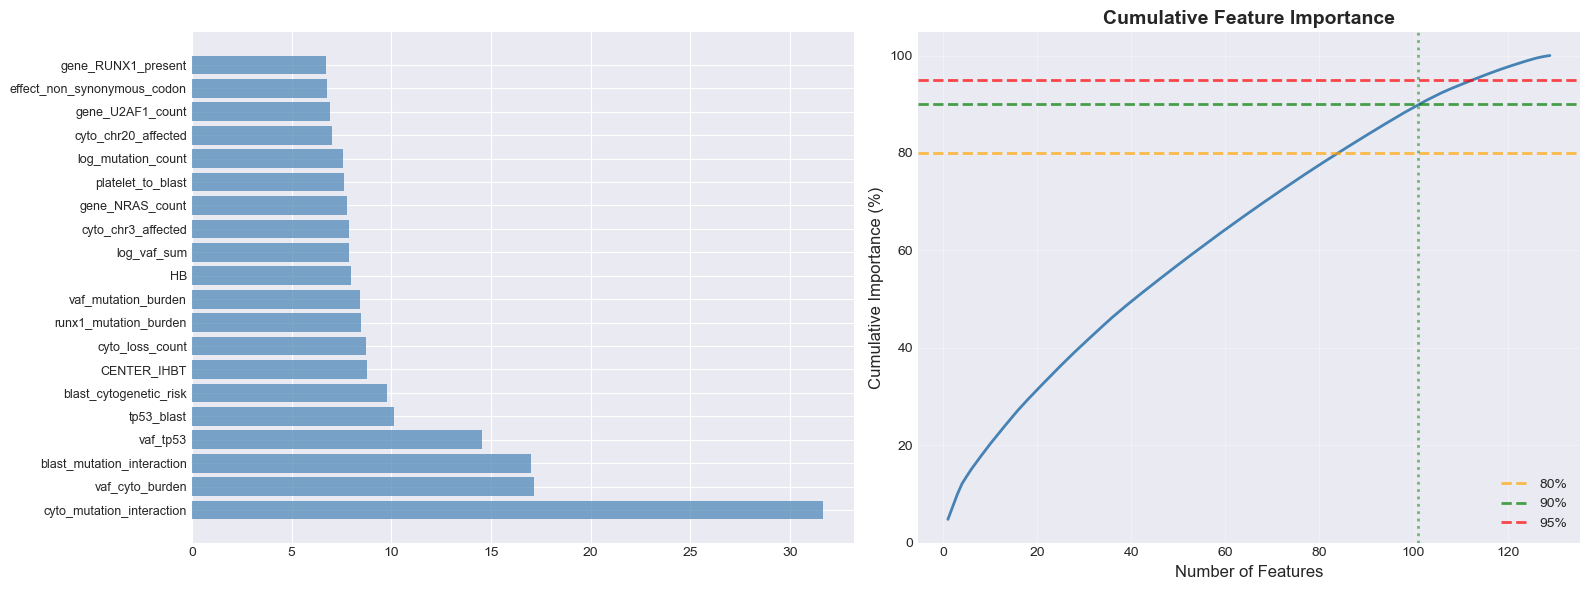

In [7]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top 20 features
top_20 = importance_df.head(20)
ax1.barh(range(len(top_20)), top_20['importance'].values, color='steelblue', alpha=0.7)
ax1.set_yticks(range(len(top_20)))
ax1.set_yticklabels(top_20['feature'].values, fontsize=9)

# Cumulative importance
ax2.plot(range(1, len(importance_df)+1), importance_df['cumulative_pct'].values * 100, 
         linewidth=2, color='steelblue')
ax2.axhline(y=80, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='80%')
ax2.axhline(y=90, color='green', linestyle='--', linewidth=2, alpha=0.7, label='90%')
ax2.axhline(y=95, color='red', linestyle='--', linewidth=2, alpha=0.7, label='95%')
ax2.axvline(x=n_90, color='green', linestyle=':', linewidth=2, alpha=0.5)
ax2.set_xlabel('Number of Features', fontsize=12)
ax2.set_ylabel('Cumulative Importance (%)', fontsize=12)
ax2.set_title('Cumulative Feature Importance', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Feature Selection Strategy

In [8]:
print("="*60)
print("TESTING FEATURE SELECTION STRATEGIES")
print("="*60)

# Test different thresholds
thresholds = [0.80, 0.85, 0.90, 0.95, 0.99]
results_selection = []

for threshold in thresholds:
    # Select features
    n_features = (importance_df['cumulative_pct'] <= threshold).sum()
    selected_features = importance_df.head(n_features)['feature'].tolist()
    
    # Train with selected features
    X_train_selected = X_train[selected_features]
    X_val_selected = X_val[selected_features]
    
    dtrain_sel = xgb.DMatrix(X_train_selected, label=y_train_xgb)
    dval_sel = xgb.DMatrix(X_val_selected, label=y_val_xgb)
    
    model_sel = xgb.train(
        params_baseline,
        dtrain_sel,
        num_boost_round=500,
        evals=[(dval_sel, 'val')],
        early_stopping_rounds=50,
        verbose_eval=False
    )
    
    y_pred_sel = model_sel.predict(dval_sel)
    c_index_sel = concordance_index_censored(
        y_val['OS_STATUS'], y_val['OS_YEARS'], y_pred_sel
    )[0]
    
    results_selection.append({
        'Threshold': f"{threshold*100:.0f}%",
        'N_Features': n_features,
        'C-index': c_index_sel,
        'vs_Baseline': c_index_sel - c_index_baseline
    })

results_df = pd.DataFrame(results_selection)
print("\n" + results_df.to_string(index=False))

# Find best
best_idx = results_df['C-index'].idxmax()
best_threshold_pct = thresholds[best_idx]
best_n_features = results_df.loc[best_idx, 'N_Features']
best_c_index_sel = results_df.loc[best_idx, 'C-index']

print(f"\n✓ Best feature selection: {best_threshold_pct*100:.0f}% cumulative importance")
print(f"  Features: {best_n_features} (reduced from {X_train.shape[1]})")
print(f"  C-index: {best_c_index_sel:.4f}")

TESTING FEATURE SELECTION STRATEGIES

Threshold  N_Features  C-index  vs_Baseline
      80%          83 0.732061    -0.000996
      85%          92 0.733494     0.000436
      90%         101 0.737097     0.004039
      95%         112 0.731700    -0.001357
      99%         124 0.732522    -0.000535

✓ Best feature selection: 90% cumulative importance
  Features: 101 (reduced from 162)
  C-index: 0.7371


## 6. Hyperparameter Optimization with Optuna

In [9]:
print("="*60)
print("HYPERPARAMETER OPTIMIZATION")
print("="*60)

# Use best feature set
best_selected_features = importance_df.head(best_n_features)['feature'].tolist()
X_train_opt = X_train[best_selected_features]
X_val_opt = X_val[best_selected_features]

dtrain_opt = xgb.DMatrix(X_train_opt, label=y_train_xgb)
dval_opt = xgb.DMatrix(X_val_opt, label=y_val_xgb)

def objective(trial):
    params = {
        'objective': 'survival:cox',
        'eval_metric': 'cox-nloglik',
        'tree_method': 'hist',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
    }
    
    model = xgb.train(
        params,
        dtrain_opt,
        num_boost_round=500,
        evals=[(dval_opt, 'val')],
        early_stopping_rounds=50,
        verbose_eval=False
    )
    
    y_pred = model.predict(dval_opt)
    c_index = concordance_index_censored(
        y_val['OS_STATUS'], y_val['OS_YEARS'], y_pred
    )[0]
    
    return c_index

print(f"\nOptimizing with {best_n_features} features...")
print("Running 100 trials...\n")

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

best_params = study.best_params
best_c_index_opt = study.best_value

print(f"\n✓ Optimization complete")
print(f"\nBest hyperparameters:")
for param, value in best_params.items():
    print(f"  {param}: {value:.4f}" if isinstance(value, float) else f"  {param}: {value}")
print(f"\nBest C-index: {best_c_index_opt:.4f}")

HYPERPARAMETER OPTIMIZATION

Optimizing with 101 features...
Running 100 trials...



  0%|          | 0/100 [00:00<?, ?it/s]


✓ Optimization complete

Best hyperparameters:
  learning_rate: 0.0744
  max_depth: 3
  min_child_weight: 9
  subsample: 0.6194
  colsample_bytree: 0.8872
  reg_alpha: 0.0124
  reg_lambda: 0.0043
  gamma: 0.0600

Best C-index: 0.7413


## 7. Final Optimized Model

In [10]:
print("="*60)
print("FINAL OPTIMIZED MODEL")
print("="*60)

# Train final model with best params
final_params = {
    'objective': 'survival:cox',
    'eval_metric': 'cox-nloglik',
    'tree_method': 'hist',
    **best_params
}

model_final = xgb.train(
    final_params,
    dtrain_opt,
    num_boost_round=500,
    evals=[(dval_opt, 'val')],
    early_stopping_rounds=50,
    verbose_eval=False
)

y_pred_final = model_final.predict(dval_opt)
c_index_final = concordance_index_censored(
    y_val['OS_STATUS'], y_val['OS_YEARS'], y_pred_final
)[0]

print(f"\nFinal model C-index: {c_index_final:.4f}")

FINAL OPTIMIZED MODEL

Final model C-index: 0.7413


## 8. Performance Comparison

In [ ]:
print("="*60)
print("PERFORMANCE COMPARISON")
print("="*60)

comparison = pd.DataFrame([
    {'Model': 'V4 RSF Baseline', 'Features': 90, 'C-index': 0.7404},
    {'Model': 'XGB All Features', 'Features': X_train.shape[1], 'C-index': c_index_baseline},
    {'Model': 'XGB Selected Features', 'Features': best_n_features, 'C-index': best_c_index_sel},
    {'Model': 'XGB Optimized (Final)', 'Features': best_n_features, 'C-index': c_index_final}
])

print("\n" + comparison.to_string(index=False))

improvement = c_index_final - 0.7404
improvement_vs_baseline = c_index_final - c_index_baseline

print(f"\n📊 Improvements:")
print(f"  vs V4 RSF:           {improvement:+.4f}")
print(f"  vs XGB Baseline:     {improvement_vs_baseline:+.4f}")
print(f"  Feature reduction:   {X_train.shape[1]} → {best_n_features} ({(1-best_n_features/X_train.shape[1])*100:.1f}% reduction)")

In [ ]:
# Visualization
fig, ax = plt.subplots(figsize=(12, 6))

models = ['V4\nRSF', 'XGB\nAll', 'XGB\nSelected', 'XGB\nOptimized']
scores = [0.7404, c_index_baseline, best_c_index_sel, c_index_final]
colors = ['#808080', '#2E86AB', '#F18F01', '#27AE60']

bars = ax.bar(models, scores, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

for bar, score in zip(bars, scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{score:.4f}',
            ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.axhline(y=0.74, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='Baseline')
ax.axhline(y=0.75, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Target: 0.75')
ax.axhline(y=0.76, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Goal: 0.76')

ax.set_ylabel('C-index (Validation)', fontsize=12)
ax.set_title('XGBoost Optimization Progress', fontsize=14, fontweight='bold')
ax.set_ylim([0.72, max(0.77, c_index_final + 0.01)])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 9. Test Set & Submission

In [ ]:
print("="*60)
print("PREPARING TEST SET")
print("="*60)

# Create features for test (same pipeline)
cyto_features_test = create_cytogenetic_features(clinical_test)
test_patient_ids = clinical_test['ID'].unique()
mol_features_test = create_molecular_features(molecular_test, test_patient_ids)

clinical_test_indexed = clinical_test.set_index('ID')
X_numeric_test = clinical_test_indexed[numeric_features].copy()
center_encoded_test = pd.get_dummies(clinical_test_indexed['CENTER'], prefix='CENTER', drop_first=True)
for col in center_encoded.columns:
    if col not in center_encoded_test.columns:
        center_encoded_test[col] = 0
center_encoded_test = center_encoded_test[center_encoded.columns]
X_clinical_test = pd.concat([X_numeric_test, center_encoded_test], axis=1)

mol_features_test_aligned = mol_features_test.reindex(X_clinical_test.index, fill_value=0)
cyto_features_test_aligned = cyto_features_test.reindex(X_clinical_test.index, fill_value=0)
X_test_base = pd.concat([X_clinical_test, mol_features_test_aligned, cyto_features_test_aligned], axis=1)

X_test_all = create_advanced_features(X_test_base)

for col in X_imputed.columns:
    if col not in X_test_all.columns:
        X_test_all[col] = 0
X_test_all = X_test_all[X_imputed.columns]

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test_all),
    index=X_test_all.index,
    columns=X_test_all.columns
)

# Select optimized features
X_test_opt = X_test_imputed[best_selected_features]

print(f"✓ Test set prepared: {X_test_opt.shape}")

In [ ]:
print("\nRetraining on full dataset...")

# Full training set
X_full_opt = X_imputed[best_selected_features]
y_full_xgb = target_clean['OS_YEARS'].copy()
y_full_xgb[~target_clean['OS_STATUS']] = -y_full_xgb[~target_clean['OS_STATUS']]

dfull_opt = xgb.DMatrix(X_full_opt, label=y_full_xgb)

model_full = xgb.train(
    final_params,
    dfull_opt,
    num_boost_round=model_final.best_iteration,
    verbose_eval=False
)

print("✓ Model retrained")

In [ ]:
# Generate predictions
dtest_opt = xgb.DMatrix(X_test_opt)
predictions_test = model_full.predict(dtest_opt)

# Convert to risk scores
min_pred = predictions_test.min()
max_pred = predictions_test.max()
risk_scores = 1 - (predictions_test - min_pred) / (max_pred - min_pred)

submission = pd.DataFrame({
    'ID': X_test_opt.index,
    'risk_score': risk_scores
})

submission_path = f"{DATA_PATH}\\submission_v6.1_xgb_optimized.csv"
submission.to_csv(submission_path, index=False)

print("="*60)
print("SUBMISSION GENERATED")
print("="*60)
print(f"File: {submission_path}")
print(f"Predictions: {len(submission)}")
print(f"\n📊 Risk Scores (0-1):")
print(submission['risk_score'].describe())

## 10. Summary

In [ ]:
print("="*60)
print("VERSION 6.1 - XGBOOST OPTIMIZATION SUMMARY")
print("="*60)

print("\n🎯 OPTIMIZATION PROCESS:")
print(f"  1. Started with {X_train.shape[1]} features")
print(f"  2. Feature selection → {best_n_features} features ({(1-best_n_features/X_train.shape[1])*100:.1f}% reduction)")
print(f"  3. Hyperparameter tuning with Optuna (100 trials)")

print("\n📈 RESULTS:")
print(f"  Baseline (all features):  {c_index_baseline:.4f}")
print(f"  Selected features:        {best_c_index_sel:.4f}")
print(f"  Optimized (final):        {c_index_final:.4f}")

print("\n🚀 IMPROVEMENT:")
print(f"  vs V4 RSF:               {improvement:+.4f}")
print(f"  vs Baseline XGB:         {improvement_vs_baseline:+.4f}")

if c_index_final >= 0.76:
    print("\n🏆 GOAL EXCEEDED! (C-index ≥ 0.76)")
elif c_index_final >= 0.75:
    print("\n🎯 TARGET REACHED! (C-index ≥ 0.75)")
elif c_index_final > 0.74:
    print("\n✅ IMPROVED vs Baseline!")

print("\n✅ OPTIMIZATIONS APPLIED:")
print(f"  ✓ Feature selection: {best_n_features} features")
print(f"  ✓ Optimized learning_rate: {best_params['learning_rate']:.4f}")
print(f"  ✓ Optimized max_depth: {best_params['max_depth']}")
print(f"  ✓ Optimized regularization: alpha={best_params['reg_alpha']:.4f}, lambda={best_params['reg_lambda']:.4f}")

print("\n✅ OUTPUT:")
print(f"  Submission: submission_v6.1_xgb_optimized.csv")
print(f"  Ready for submission!")